In [725]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
sns.set_palette('muted')


1 — Basic Exploration


In [726]:
df=pd.read_csv('data/Sample - Superstore.csv',encoding='windows-1252')
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


In [727]:
# How many rows and columns are in the dataset?
df.shape

(9994, 21)

In [728]:
# Print all column names and their data types.
df.columns
# Check for missing values and duplicates.
# How many unique Customers, Products, and Cities are there?

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [729]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [730]:
# Check for missing values and duplicates.
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [731]:
df.duplicated().sum()

np.int64(0)

In [732]:
# How many unique Customers, Products, and Cities are there?
# ✅ Cleaner as one block
print(f"Unique Customers : {df['Customer ID'].nunique()}")
print(f"Unique Products  : {df['Product ID'].nunique()}")
print(f"Unique Cities    : {df['City'].nunique()}")

Unique Customers : 793
Unique Products  : 1862
Unique Cities    : 531


🔹 Level 2 — Data Cleaning

In [733]:
# Convert Order Date and Ship Date to datetime format.
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])


In [734]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [735]:
# Create a new column Processing Days = Ship Date − Order Date (number of days to ship).
df['Processing Days']=df['Ship Date']-df['Order Date']
# Check if Processing Days has any negative or zero values — remove them if found.
(df['Processing Days']<=pd.Timedelta(days=0)).sum()#519 

np.int64(519)

In [736]:
# df[df['Processing Days']=='0 days']
df=df[df['Processing Days']>pd.Timedelta(days=0)]
(df['Processing Days']<=pd.Timedelta(days=0)).sum()#0

np.int64(0)

In [737]:
# Strip any leading/trailing whitespace from all string columns.
df=df.apply(lambda x:x.str.strip() if x.dtype=='object' else x)


In [738]:
# Confirm the final cleaned shape of the dataset.
df.shape

(9475, 22)

3 — Feature Engineering

In [739]:
# Extract Order Year, Order Month, and Order Quarter from Order Date.
df['Order Year']=df['Order Date'].dt.year
df['Order Month']=df['Order Date'].dt.month
df['Order Quarter']=df['Order Date'].dt.quarter

In [740]:
# Create a Profit Margin % column = (Profit / Sales) * 100. Round to 2 decimal places.
df['Profit Margin (%)']=round((df['Profit']/df['Sales'])*100,ndigits=2)

In [741]:
# Create a Loss column — True if Profit is negative, False otherwise.
df['Loss']=df['Profit']<0

In [742]:
# Bin the Sales column into 4 categories using pd.cut(): Low (0–100), Medium (100–500), High (500–1000), Very High (1000+)
df['Sales Category']=pd.cut(df['Sales'],bins=[0,100,500,1000,float('inf')],labels=['Low (0-100)','Medium (100–500)','High (500–1000)','Very High (1000+)'])

In [743]:
# How many orders fall in each sales bin?
df['Sales Category'].value_counts()

Sales Category
Low (0-100)          5910
Medium (100–500)     2468
High (500–1000)       661
Very High (1000+)     436
Name: count, dtype: int64

4 — Business Insights

In [744]:
# Which Region generates the most total Sales?
sales_by_region=df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sales_by_region

Region
West       684960.8285
East       635454.4080
Central    481147.8568
South      370730.0760
Name: Sales, dtype: float64

In [745]:
# Which Category is most profitable? Which is least profitable?
df.groupby('Category')['Profit'].sum().idxmax()#'Technology'

'Technology'

In [746]:
df.groupby('Category')['Profit'].sum().idxmin()#'Furniture'

'Furniture'

In [747]:
# Which Sub-Category has the highest average discount?
s=df.groupby('Sub-Category')['Discount'].mean()#'Binders'
print(s.idxmax(),round(s.max(),ndigits=2))

Binders 0.37


In [748]:
# What are the Top 5 most profitable products?
df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(5)


Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            5807.9032
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Name: Profit, dtype: float64

In [749]:
# What are the Top 5 loss-making products? (lowest profit)
df.groupby('Product Name')['Profit'].sum().sort_values(ascending=True).head(5)

Product Name
Cubify CubeX 3D Printer Double Head Print                  -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                  -4589.9730
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases   -2876.1156
Bush Advantage Collection Racetrack Conference Table       -1934.3976
GBC DocuBind P400 Electric Binding System                  -1878.1662
Name: Profit, dtype: float64

In [750]:
# Which Customer has placed the most orders?
df.groupby('Customer Name')['Order ID'].nunique().idxmax()

'Emily Phan'

In [751]:
# What is the monthly sales trend — which month has highest total sales across all years?
monthly_sales=df.groupby('Order Month')['Sales'].sum() #Novermber have highest sales in  all year
monthly_sales

Order Month
1      94186.1466
2      57542.7514
3     194592.4778
4     134774.3046
5     146592.7787
6     145457.5863
7     131704.2860
8     153816.0210
9     289477.3287
10    185833.2147
11    328044.7270
12    310271.5465
Name: Sales, dtype: float64

In [752]:
# Sales across years 
df.groupby('Order Year')['Sales'].sum()

Order Year
2014    466971.6861
2015    443195.7910
2016    575278.7010
2017    686846.9912
Name: Sales, dtype: float64

In [753]:
# Progit over years 
df.groupby('Order Year')['Profit'].sum()

Order Year
2014    46879.8758
2015    57321.5538
2016    76352.4148
2017    90457.2088
Name: Profit, dtype: float64

In [754]:
# Which Ship Mode is used most often?
df.groupby('Ship Mode')['Order ID'].count().idxmax()#Standard Class ship mode is most often use 5968 time over all the years 
# Is there a relationship between Discount and Profit? Compute their correlation.

'Standard Class'

In [755]:
# Which State has the highest total loss (most negative profit)?
df.groupby('State')['Profit'].sum().idxmin()# Texas over loss of $24853

'Texas'

In [756]:
df['Discount'].corr(df['Profit'])

np.float64(-0.21983309817525132)

<Axes: >

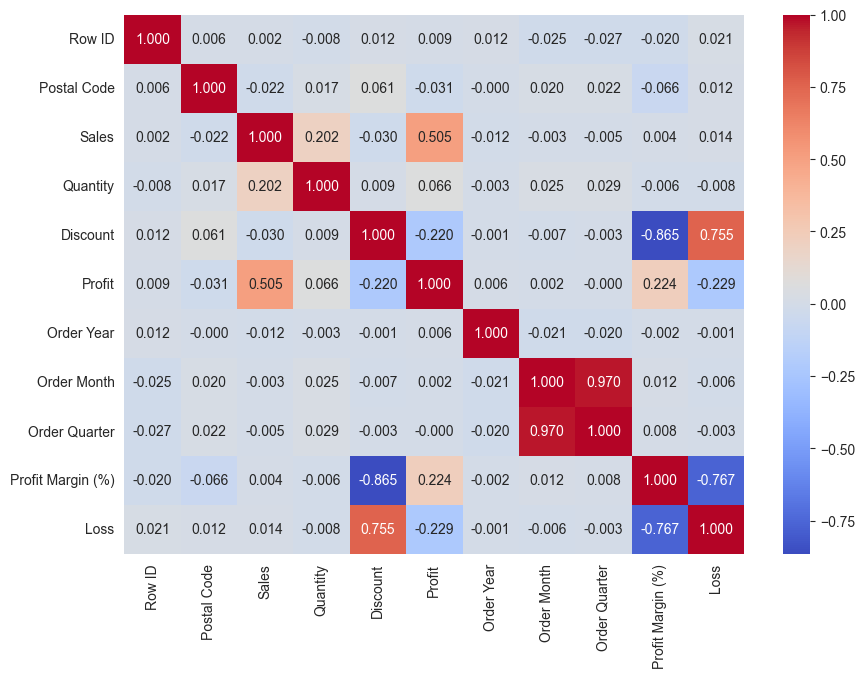

In [757]:
# Is there a relationship between Discount and Profit? Compute their correlation.
corr=df.corr(numeric_only=True)
plt.figure(figsize=(10,7))
sns.heatmap(corr,annot=True,fmt='.3f',cmap='coolwarm')
# there -0.220 we can say that as higher the discount = lower the profit 

 5 — Visualization


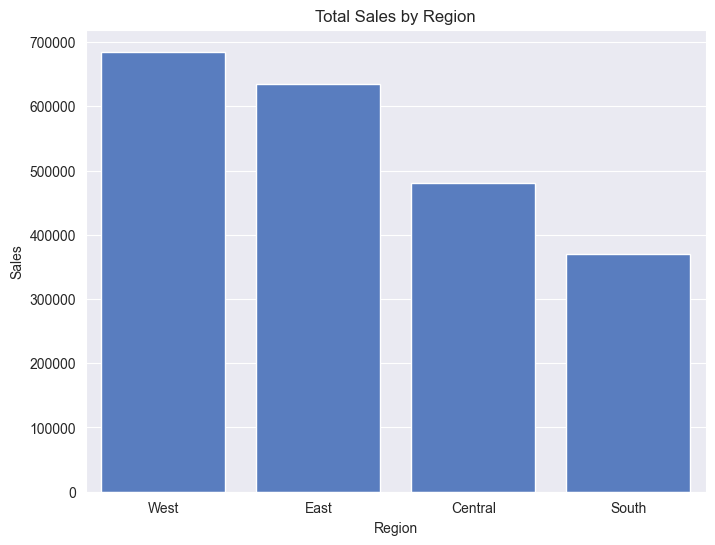

In [758]:
# Bar chart — Total Sales by Region.
plt.figure(figsize=(8,6))
sns.barplot(sales_by_region)
plt.xlabel('Region')
plt.ylabel('Sales')
plt.title('Total Sales by Region')
plt.show()



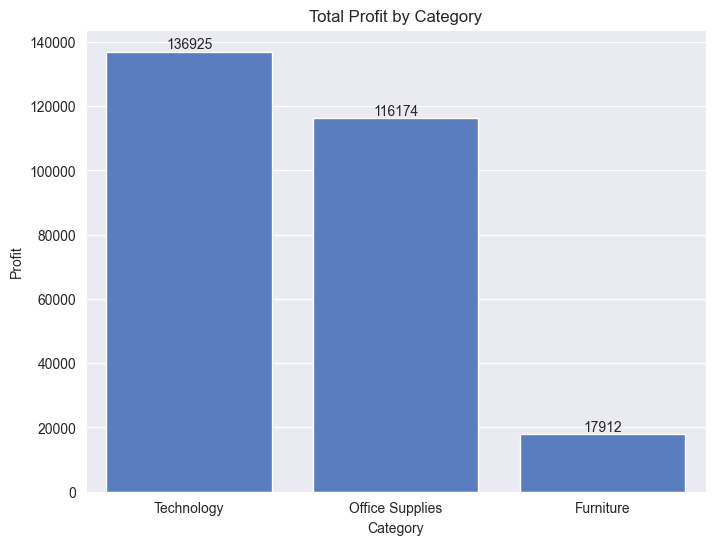

In [759]:
# Bar chart — Total Profit by Category.
profit_by_category=df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,6))

ax=sns.barplot(x=profit_by_category.index,y=profit_by_category.values)
for i,v in enumerate(profit_by_category.values):
    ax.text(i,v,f'{v:.0f}',ha='center',va='bottom')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.title('Total Profit by Category')
plt.show()


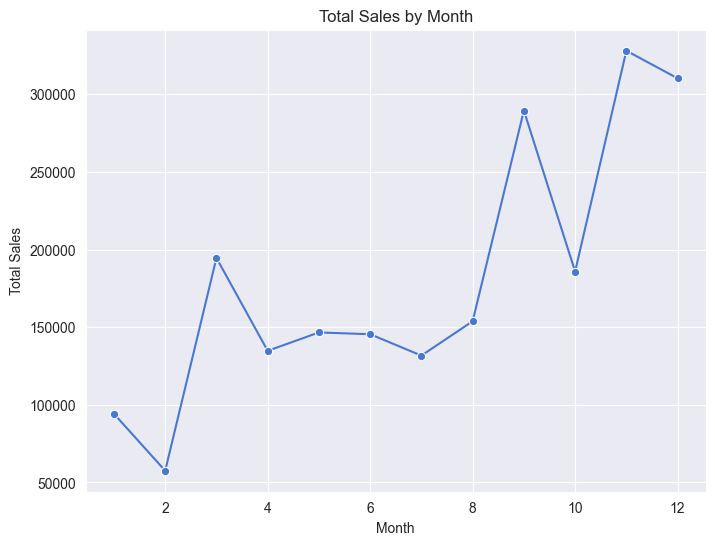

In [760]:
# Line chart — Monthly Sales trend (use Order Month).
plt.figure(figsize=(8,6))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Total Sales by Month')
plt.show()


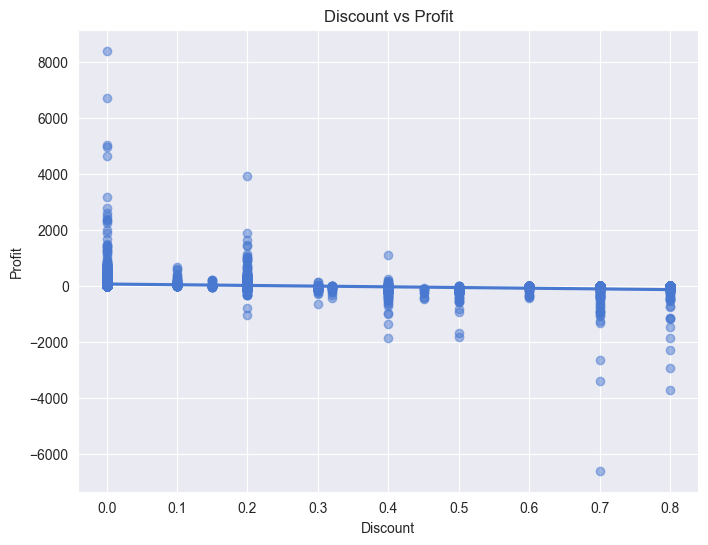

In [761]:
# Scatter plot — Discount vs Profit with regression line (sns.regplot).
plt.figure(figsize=(8,6))
sns.regplot(data=df, x='Discount', y='Profit', scatter_kws={'alpha':0.5})
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit')
plt.show()


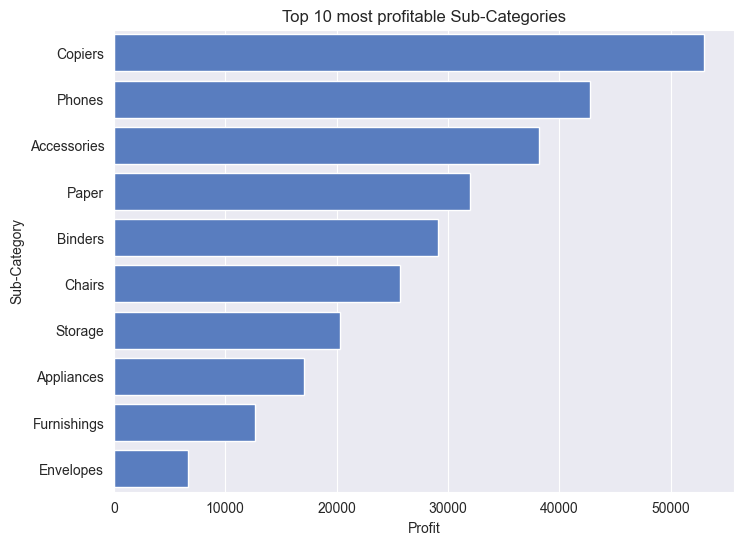

In [762]:
# Horizontal bar chart — Top 10 most profitable Sub-Categories.
top_10_subcategories_by_profit=df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,6))
sns.barplot( x=top_10_subcategories_by_profit.values, y=top_10_subcategories_by_profit.index,orient='h')
plt.xlabel('Profit')
plt.ylabel('Sub-Category')
plt.title('Top 10 most profitable Sub-Categories')
plt.show()


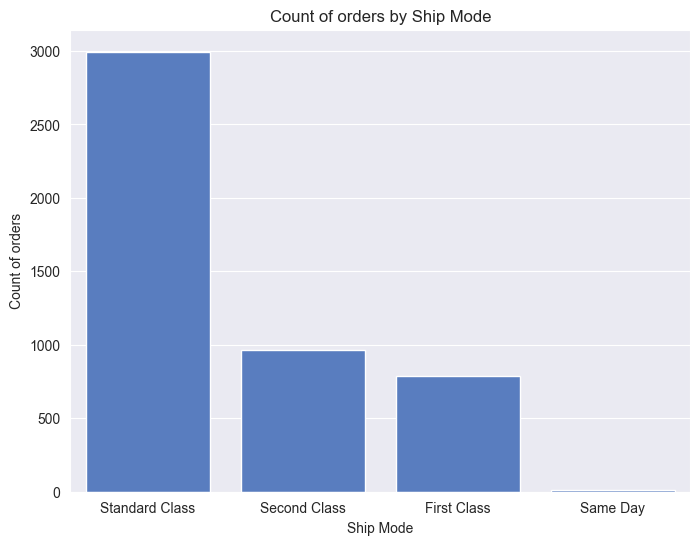

In [ ]:
# Bar chart — Count of orders by Ship Mode.
oder_count_by_ship_mode=df.groupby('Ship Mode')['Order ID'].nunique().sort_values(ascending=False)
oder_count_by_ship_mode
plt.figure(figsize=(8,6))
sns.barplot(y=oder_count_by_ship_mode.values, x=oder_count_by_ship_mode.index)
plt.xlabel('Ship Mode')
plt.ylabel('Count of orders')
plt.title('Count of orders by Ship Mode')
plt.show()

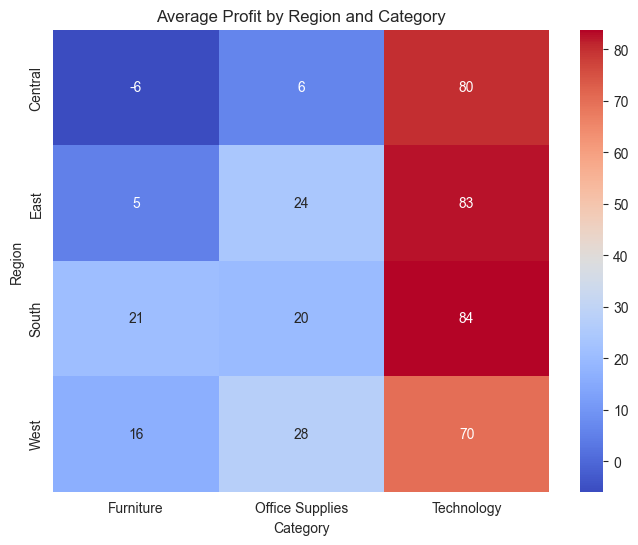

In [764]:
# Heatmap — Pivot table of average Profit by Region (rows) and Category (columns).
pivot=df.pivot_table(index='Region',columns='Category',values='Profit',aggfunc='mean')
plt.figure(figsize=(8,6))
sns.heatmap(pivot,annot=True,cmap='coolwarm',fmt='.0f')
plt.title('Average Profit by Region and Category')
plt.xlabel('Category')
plt.ylabel('Region')
plt.show()
